# Playground

# Operator

This is the top level of management that connetcs `Registry` to generate data from the dataset *(selected slides in dataset.csv)*

- The `data_paths` are then saved into an internal cache **slide_data_paths** in `Manager` for accessing any **data modes**
- The `tile_extractions` are then saved with **keys** of `tile_class`  in `Manager` 
    - for **accessing extractions** from any **tile class** *(the dataset its referenced from)*

`Operator` is a higher level class that simplifies further for usage of manager resources

Setting up the environmnet:
1. `root_dir` is the location of the database
2. `models_save_dir` is the location of the foundational models used for extracting slide embeddings
3. Assign `Backbone` as the model storage for different foundational models
4. Assign `Operator` as the main interface

Note: 
- `Operator` is defined per `session` *(1 user may have 1+1: generating and interface)*
- `Backbone` is shared for all

## Setup

In [14]:
# for notebook
import sys
sys.path.append('..')

import apeiron as ap
from matplotlib import pyplot as plt
import numpy as np

root_dir = "/mnt/a/APEIRON_v1/DATABASE"
models_save_dir = "/mnt/a/APEIRON_v1/MODELS/foundational_models"

backbone = ap.Backbone(models_save_dir)
operator = ap.Operator(backbone=backbone, root_dir=root_dir)

Device: GPU (NVIDIA GeForce RTX 4070 Ti SUPER)


You can **reset** the `operator` to different *project_path* via `setup`

In [15]:
# Here we just use back project_path as ../user1/task1
project_path = "/mnt/a/APEIRON_v1/PROJECTS/user1/task3_breast_cam"
# project_path = "/mnt/a/APEIRON_v1/PROJECTS/user1/task5_gleason_kag"
# project_path = "/mnt/a/APEIRON_v1/PROJECTS/user1/task2"

operator.setup(project_path)

example_name = operator.collector.slide_dataset['slide_name'][0]
example_id = operator.collector.slide_dataset['slide_id'][0]
print('name:', example_name, 'id:', example_id)

operator.collector.slide_dataset

Device: GPU (NVIDIA GeForce RTX 4070 Ti SUPER)
name: normal_001 id: fe02c30459704179a38bae0cfa901d92


,slide_id,slide_name,slide_path,slide_class,class0,class1,class2,class3
0,fe02c30459704179a38bae0cfa901d92,normal_001,breast_cam/normal_001.tif,breast_cam,0,1,0,0
1,37fe42f7ad6345399e86c42647dcbb94,normal_002,breast_cam/normal_002.tif,breast_cam,0,1,0,0
2,aac5cb277327481fb96a42bd86f1e6a3,normal_003,breast_cam/normal_003.tif,breast_cam,0,1,0,0
3,25ff0d7172f148ed8824d1760bd4f322,normal_004,breast_cam/normal_004.tif,breast_cam,0,1,0,0
4,fc42f33e8a8840d28a3eb8b17ce13013,normal_005,breast_cam/normal_005.tif,breast_cam,0,1,0,0
...,...,...,...,...,...,...,...,...
394,aeeeba80b5c242608565776c7e826b8b,tumor_107,breast_cam/tumor_107.tif,breast_cam,0,0,1,0
395,52b99078509c4121b6820f6c3c7dce80,tumor_108,breast_cam/tumor_108.tif,breast_cam,0,0,0,1
396,717595d41c394d30ae13076a69e4d879,tumor_109,breast_cam/tumor_109.tif,breast_cam,0,0,0,1
397,81e6cd84b258426e8e0413f31d847e10,tumor_110,breast_cam/tumor_110.tif,breast_cam,0,0,0,1


You can ingest data for both slide and tile datasets like this

- `data_class` are the **directories** *(folder name in the database)*
- `base_mpps` are the **base mpp** *(tile only)*
- `mode` is either **slide** or **tile**

`operator.create_datasets` takes a **pre-existing label csv** and **join it** with the **registry data frame**

In [16]:
# ## COMMENT THESE ###
# operator.ingest_data(data_classes=['gleason_kag'], mode='slide')
# operator.ingest_data(data_classes=['lung_colon', 'pancancer'], base_mpps=[0.5, 0.5], mode='tile')
# operator.create_datasets('dataset.csv', 'LABEL', mode='slide')

You can `query` the dataset to `select which slides` to *generate*

In [17]:
# operator.query_slide_dataset(slide_ids=["ac308d3bccc94c389a0211a51dbe95aa", "0053594aace2405b9a7643f3a269b55c"], select_all=False)
# operator.query_tile_dataset(tile_ids=["f05332b1109e4899b09fd21c5596c8b6", "f9edaba70cfd4b7ea2192dbce232a32c"], select_all=False)
# operator.selected_slide_dataset

You can also **look up** the `id from name` or get the `name from id`

with `to_id` as a bool

*(inputs a list or str and returns a list)*

In [18]:
operator.lookup_table([example_name], mode='slide', to_id=True)

['fe02c30459704179a38bae0cfa901d92']

## Generate

you can set **io_mode** of `operator` to `'r' or 'w'`, 
- `read` allows assigning `slide_data_paths` internally **without any saving or generating**
- `write` is for **data generation**

In [19]:
operator.set_io_mode('w')

Generating `thumbnails`, options include:
- "slide_thumbnail"
- "masked_thumbnail"
- "normalised_thumbnail"

*Note: normalised_thumbnail not realy useful here, tend to not generate*

In [20]:
operator.generate_thumbnails(modes=["slide_thumbnail", "masked_thumbnail"])

399it [00:02, 134.68it/s]


Generating **slide** `embeddings`, options include:
- "batch_size"
- "num_workers"

In [21]:
operator.generate_embeddings_slide(batch_size=300, num_workers=4)

Model not loaded yet.
Loading Model ...

Model loaded from /mnt/a/APEIRON_v1/MODELS/foundational_models/hop0/hop0.pth
model used: hop0
transform applied: Compose(
      ToImage()
      Resize(size=[224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      CenterCrop(size=(224, 224))
      ToDtype(scale=True)
      Normalize(mean=[0.707223, 0.578729, 0.703617], std=[0.211883, 0.230117, 0.177517], inplace=False)
))


399it [00:03, 114.06it/s]


Generating `feats color`, for the **reduced slide embeddings** *(F dim to 3 dim, RGB)*

In [22]:
operator.generate_feats_color()

399it [00:03, 117.85it/s]


Generating **tile** `embeddings`, options include:
- "batch_size"
- "num_workers"
- "chunk_size" - how much tiles to reside in a single chunk, defaults to 10,000

In [23]:
operator.generate_embeddings_tile(batch_size=300, num_workers=4)

## Serve as analyzer

`Operator` can also *serve* a analyzer object from slide name *(taken from dataset.csv)*

- It works exactly like `Analyzer` and **pre-load** all the generated `data_modes` done above
- Its attached to the `operator` object *(save memory)*, so remember to **serve again** after 'read' data

In [24]:
slide_id = operator.lookup_table(example_name, mode='slide')[0]
analyzer = operator.serve_slide_analyzer(slide_id, data_modes='req')

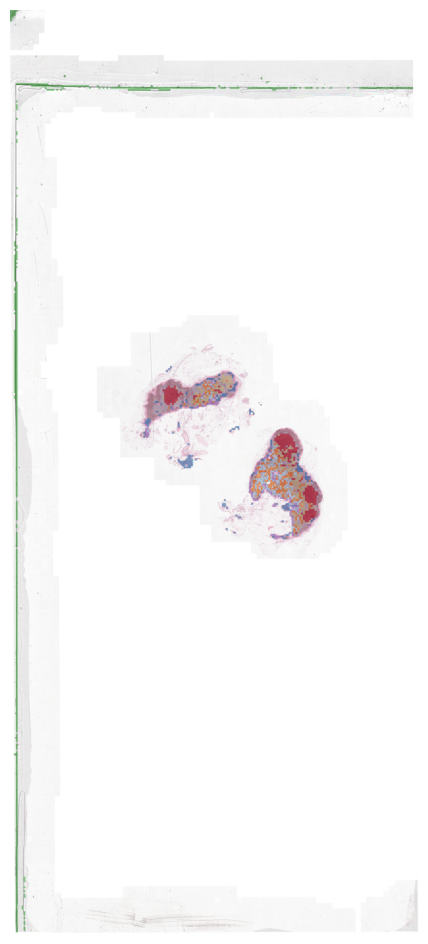

array([[[148, 206, 148],
        [148, 206, 148],
        [148, 206, 148],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[112, 168, 110],
        [112, 168, 110],
        [111, 167, 110],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[114, 170, 112],
        [114, 170, 112],
        [114, 170, 112],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]]

In [25]:
analyzer.compute_feats_color(n_clusters=10)
analyzer.create_feature_viz(mode='clusters')
analyzer.visualise_overlay(alpha=0.5)

## Collect data

Here we see the printed values for slide

In [ ]:
slide_ids = operator.lookup_table([example_name], mode='slide')
collected = next(operator.slide_features_collector(collect_ids=slide_ids))

slide_collected_data = collected.copy()
print(collected.keys())

print("slide id:", collected.pop('id'), "\nshapes of each data:")
for k, v in collected.items():
    try:
        print(k, v.shape)
    except:
        print(k, v)

dict_keys(['coords', 'features', 'objects', 'coords_size', 'data_type', 'propagate_loss', 'id', 'label', 'text'])
slide id: fe02c30459704179a38bae0cfa901d92 
shapes of each data:
coords (1, 2642, 2)
features (1, 2642, 1536)
objects [[]]
coords_size 461
data_type single
propagate_loss True
label (1, 4)
text None


Serve the **slide** and we can create a **HW3 RGB image** as `overlay` *(downscaled based on thumbnail)*

In [10]:
analyzer = operator.serve_slide_analyzer(slide_collected_data['id'], data_modes='ann')
print("slide id:", slide_collected_data['id'])
viz = analyzer.create_annotation_viz(heatmap_target=2, mode='annotation')
viz.show()

slide id: fe02c30459704179a38bae0cfa901d92


TypeError: 'NoneType' object is not subscriptable

Here we see the printed values for tile

In [ ]:
tile_ids = operator.lookup_table(["colon_ade_colonca95"], mode='tile')
collected = next(operator.tile_features_collector(collect_ids=tile_ids, cache=False))

tile_collected_data = collected.copy()
print(collected.keys())

print("tile id:", collected.pop('id'), "\nshapes of each data:")
for k, v in collected.items():
    try:
        print(k, v.shape)
    except:
        print(k, v)

dict_keys(['split_id', 'coords', 'features', 'coords_size', 'data_type', 'propagate_loss', 'id', 'label', 'text'])
tile id: ['ec46f6b22598446e9509c4b1e5ba3487'] 
shapes of each data:
split_id (1,)
coords (1, 2)
features (1, 3072)
coords_size 224
data_type single
propagate_loss True
label (1, 6)
text (1,)


## Downstream

Training & Evaluation

In [29]:
operator.intitalise_inferencer(mode='tile')
batch_size = 4
operator.train(n_epochs=3, batch_size=batch_size)
operator.evaluate(batch_size=batch_size)

AttributeError: 'NoneType' object has no attribute 'losser'

In [30]:
operator.intitalise_inferencer(mode='slide')
batch_size = 4
operator.train(n_epochs=3, batch_size=batch_size)
eval_dict = operator.evaluate(batch_size=batch_size)


SPLIT SUMMARY (By Slide ID)
Total Slides: 399
Train: 319 | Valid: 80
            Train Portion (%)  Valid Portion (%)
temp_label                                      
class1                  59.87               60.0
class2                  20.06               20.0
class3                  20.06               20.0

Result -> mnf_id: inf_1, epoch: 0


319it [07:26,  1.40s/it]
80it [01:41,  1.27s/it]


Epoch 1/3 | train loss: 0.9556 | valid loss: 0.7617 | lr: 1.00e-04


319it [05:29,  1.03s/it]
80it [01:32,  1.16s/it]


Epoch 2/3 | train loss: 0.5302 | valid loss: 0.3377 | lr: 1.00e-04


319it [05:53,  1.11s/it]
80it [01:30,  1.13s/it]


Epoch 3/3 | train loss: 0.2431 | valid loss: 0.1253 | lr: 1.00e-04


80it [00:58,  1.37it/s]


In [45]:
operator.intitalise_inferencer(mode='slide', inf_id=3, load_epoch=3)
# slide_id = operator.lookup_table("TCGA-2A-A8W3-01Z-00-DX1", mode='slide')[0]
analyzer = operator.serve_slide_analyzer(example_id, data_modes='pred')
print(analyzer.mdatas[0].pred.pred_lbl)


SPLIT SUMMARY (By Slide ID)
Total Slides: 399
Train: 319 | Valid: 80
            Train Portion (%)  Valid Portion (%)
temp_label                                      
class1                  59.87               60.0
class2                  20.06               20.0
class3                  20.06               20.0

Result -> mnf_id: inf_1, epoch: 3
Loaded epoch: 3
tensor([[1.1372e-05, 9.8933e-01, 1.0644e-02, 1.3102e-05]])


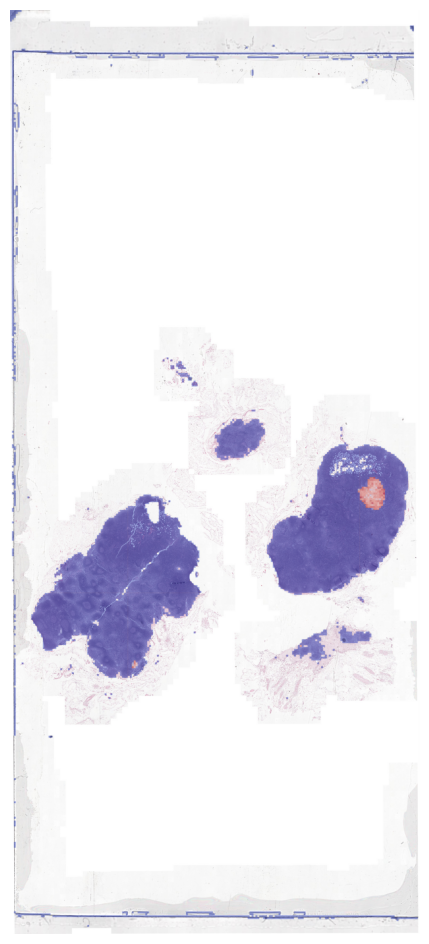

array([[[155, 164, 222],
        [155, 164, 222],
        [155, 164, 222],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[125, 132, 190],
        [125, 132, 190],
        [124, 131, 190],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[126, 133, 191],
        [126, 133, 191],
        [125, 132, 191],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]]

In [44]:
viz = analyzer.create_annotation_viz(heatmap_target=2, n_obj=5, mode='pred_atn')
viz.show()

## Searcher

In [ ]:
slide_id = operator.lookup_table("TCGA-2A-A8W3-01Z-00-DX1", mode='slide')[0]
operator.similarity_search(mode='slide', query_mode=['feat', 'roi'], query_feat_id=slide_id, query_roi_id=[0, 100, 1000])

Total samples: 195609
Training FAISS KMeans with K=16 on GPU=True...


SimDF(feat_res=                                 id  distance
0  0053594aace2405b9a7643f3a269b55c  0.000000
1  97f6a23681be4d4c9f0cc3079e3ab086  0.910029
2  7a99a1a050664d9e9258b8de9656a997  0.981227
3  de72952baf864194965b312825a875c9  1.070228
4  9d460dd26591453382129af59ad9887f  2.752589, roi_res=                                    cluster_id  composite_score  \
97f6a23681be4d4c9f0cc3079e3ab086 0           5         1.991777   
                                 1           2         1.870958   
                                 2           3         1.807743   
                                 3           0         1.664793   
                                 4           6         1.474637   
                                 5           4         1.457373   
                                 6           7         1.128541   
                                 7           8         0.972140   
                                 8           1         0.950569   
7a99a1a050664d9e9258b8de9656a9

In [ ]:
slide_ids = operator.lookup_table(["TCGA-2A-A8W3-01Z-00-DX1", "TCGA-2A-A8VV-01Z-00-DX1"], mode='slide')
operator.similarity_search(mode='slide', query_mode='img', query_feat_id=slide_ids, query_text=['hi', 'dude'])

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


SimDF(feat_res=None, roi_res=None, wrd_res=          wrd_0     wrd_1
img_0  0.023713  0.025081
img_1  0.063119  0.061831)

In [ ]:
tile_id = operator.lookup_table("colon_non-tumour_TCGA-3L-AA1B-01Z-00-DX1_10752_27136", mode='tile')[0]
operator.similarity_search(mode='tile', query_mode='feat', query_feat_id=tile_id, rebuild_index=True)


SPLIT SUMMARY (By Slide ID)
Total Slides: 31
Train: 24 | Valid: 7
            Train Portion (%)  Valid Portion (%)
temp_label                                      
class1                  45.83              42.86
class2                  33.33              28.57
class4                  20.83              28.57

Result -> mnf_id: inf_1, epoch: 3
Loaded epoch: 3
Total samples: 31
Training FAISS KMeans with K=16 on GPU=True...


WARNING clustering 31 points to 16 centroids: please provide at least 624 training points


SimDF(feat_res=                                 id     distance
0  2184ff3eda5a439b9c00f5e5c74b915e     0.000000
1  ad1dff47171941999098c121e2dadaf3   373.692657
2  08a16f3a10144a4fb3bf77edb2f8f1f9   472.662628
3  728d3a3c1cdd4466b7ebbbbda26aebc0  1603.471313
4  03ba324130a74cb6bcf85f2eaf69cd39  1753.029297, roi_res=None, wrd_res=None)

In [ ]:
tile_ids = operator.lookup_table(["colon_ade_colonca98", "colon_ade_colonca93"], mode='tile')
operator.similarity_search(mode='tile', query_mode='img', query_feat_id=tile_ids, query_text=['hi', 'dude'])

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


SimDF(feat_res=None, roi_res=None, wrd_res=          wrd_0     wrd_1
img_0 -0.031799 -0.033255
img_1 -0.002020 -0.010632)